# Predicting Tips Using Linear Regression

In this project, we'll apply the techniques we've learned to a real-world scenario: predicting tips in a restaurant setting. This practical application will help solidify our understanding of various regression methods and their implementation from scratch.

We'll be working with the 'tips' dataset, which is included in the seaborn library. This dataset contains information about tips given to waiters in a restaurant.

This dataset is particularly interesting because it allows us to explore both numerical and categorical predictors in our regression models. Our main goal is to predict the tip amount based on various factors. Throughout this project, we aim to:

1. Apply different regression techniques to a real dataset.
2. Compare the performance of various models we've implemented from scratch.
3. Gain insights into factors that influence tipping behavior.
4. Practice data preprocessing, feature engineering, and model evaluation.

**We'll follow a typical data science workflow:**
1. Data exploration and preprocessing
2. Feature selection and engineering
3. Model implementation (starting with simple models and progressively adding complexity)
4. Model evaluation and comparison
5. Interpretation of results

### Task: First, let's load the necessary libraries and the dataset:



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the tips dataset
tips_df = sns.load_dataset('tips')

### Task: Get familiar with the dataset

🔍 **Observation:** Take a moment to examine the output. Notice the data types of each column and check for any missing values.

In [2]:
# Display the first few rows and basic information
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
tips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
tips_df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


### TASK: check for missing values

In [5]:
tips_df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

💡 **Pro Tip:** If we find any missing values, we'll need to decide whether to impute them or drop the rows. In this case, the 'tips' dataset is typically clean, but it's always good practice to check.

## Exploratory Data Analysis (EDA)

### Task: encode our categorical variables

In [6]:
# Categorical encoding for 'sex', 'smoker', and 'time'
tips_df['sex'] = tips_df['sex'].cat.codes
tips_df['smoker'] = tips_df['smoker'].cat.codes
tips_df['time'] = tips_df['time'].cat.codes

# One-hot encoding for 'day'
#tips_df = pd.get_dummies(tips_df, columns=['day'], prefix='day')

day_dummies = pd.get_dummies(tips_df['day'], prefix='day')
tips_df = pd.concat([tips_df, day_dummies], axis=1)

tips_df.head()

,total_bill,tip,sex,smoker,day,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,Sun,1,2,False,False,False,True
1,10.34,1.66,0,1,Sun,1,3,False,False,False,True
2,21.01,3.50,0,1,Sun,1,3,False,False,False,True
3,23.68,3.31,0,1,Sun,1,2,False,False,False,True
4,24.59,3.61,1,1,Sun,1,4,False,False,False,True


### TASK: Historgram distribution of tips amounts

Text(0.5, 1.0, 'Distribution of Tip Amounts')

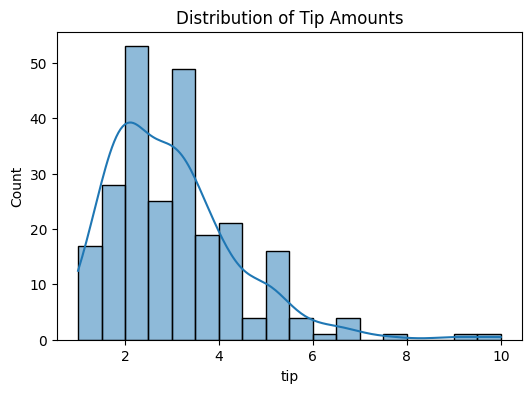

In [7]:
# Distribution of tip amounts
plt.figure(figsize=(6, 4))
sns.histplot(tips_df['tip'], kde=True)
plt.title('Distribution of Tip Amounts')

### TASK: Scatter plot of total bill vs tip amount

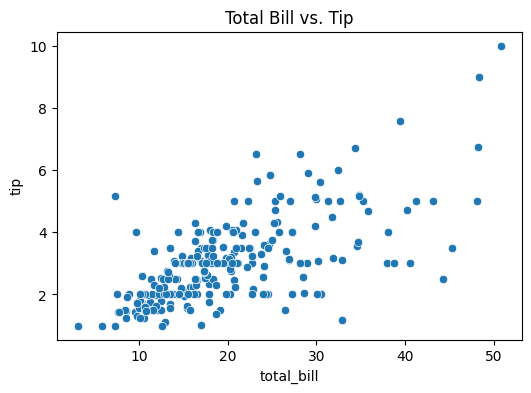

In [8]:
# Relationship between total bill and tip
plt.figure(figsize=(6, 4))
sns.scatterplot(x='total_bill', y='tip', data=tips_df)
plt.title('Total Bill vs. Tip')
plt.show()

### TASK: Joint plot of total bill vs tip amount 

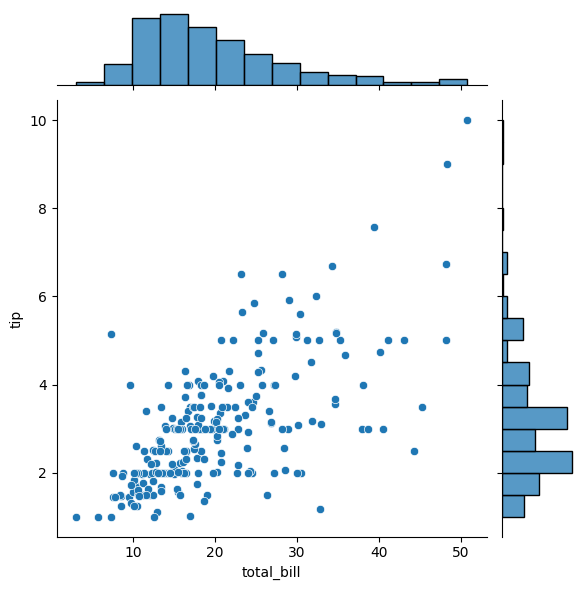

In [9]:
sns.jointplot(data=tips_df, x="total_bill", y="tip");

### TASK: Boxplots for categorical variables

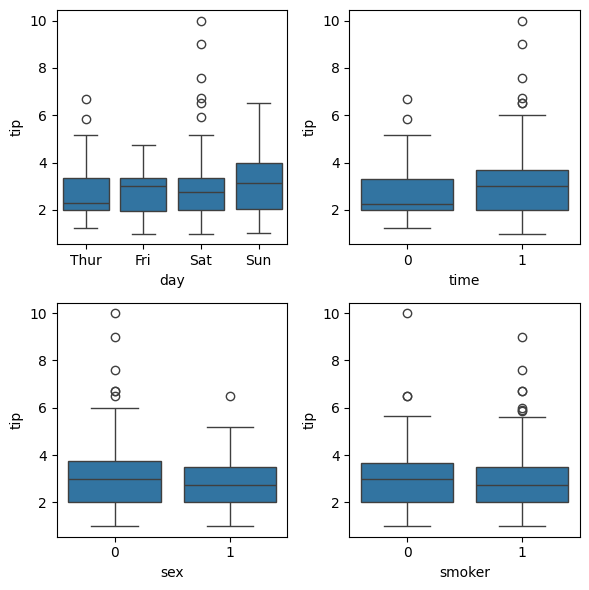

In [10]:
# Box plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.boxplot(x='day', y='tip', data=tips_df, ax=axes[0, 0])
sns.boxplot(x='time', y='tip', data=tips_df, ax=axes[0, 1])
sns.boxplot(x='sex', y='tip', data=tips_df, ax=axes[1, 0])
sns.boxplot(x='smoker', y='tip', data=tips_df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

### Task: a plot using functions from different modules (relational, distribustional, and categorical modeules)

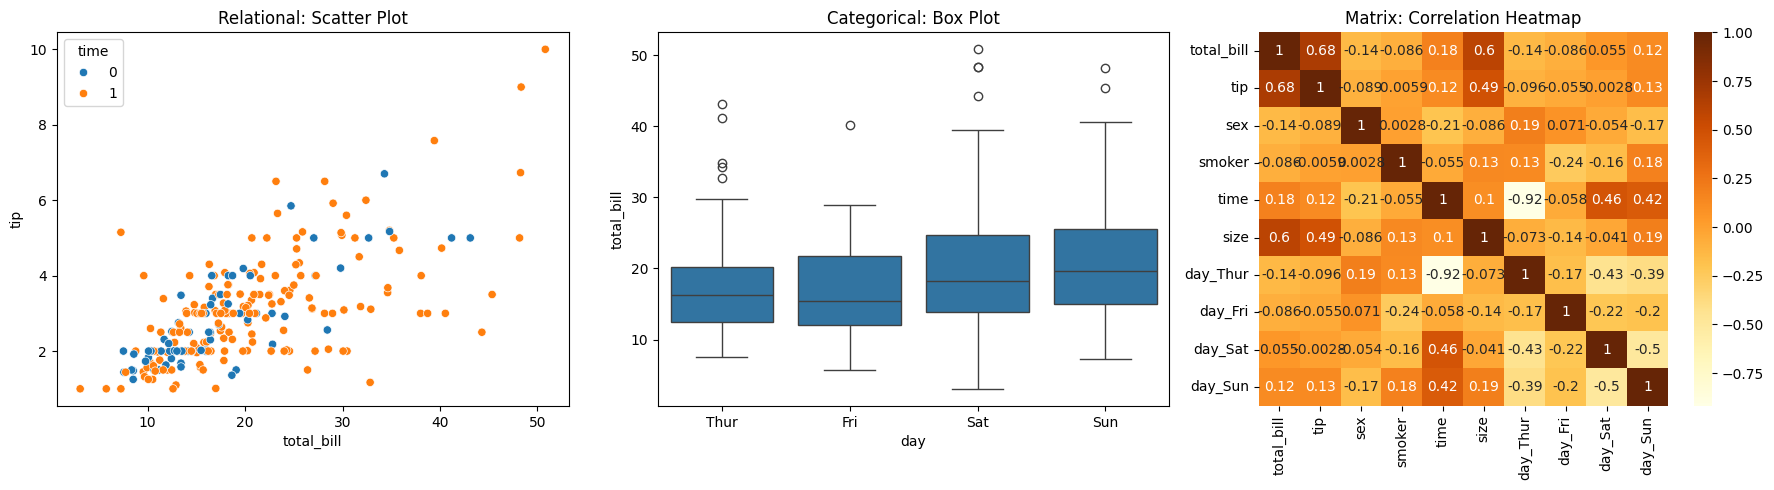

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Relational plot
sns.scatterplot(data=tips_df, x="total_bill", y="tip", hue="time", ax=ax1)
ax1.set_title("Relational: Scatter Plot")

# Categorical plot
sns.boxplot(data=tips_df, x="day", y="total_bill", ax=ax2)
ax2.set_title("Categorical: Box Plot")

# Matrix plot
corr = tips_df.corr(numeric_only=True)  # get correlations of numeric columns
sns.heatmap(corr, annot=True, cmap="YlOrBr", ax=ax3)
ax3.set_title("Matrix: Correlation Heatmap")

plt.tight_layout()

### Task: Plot the scatter plots of total bill vs. tip for different days and meals seperately.

Text(0.5, 0.98, 'Figure-level: Faceted Scatter Plots')

<Figure size 1800x500 with 0 Axes>

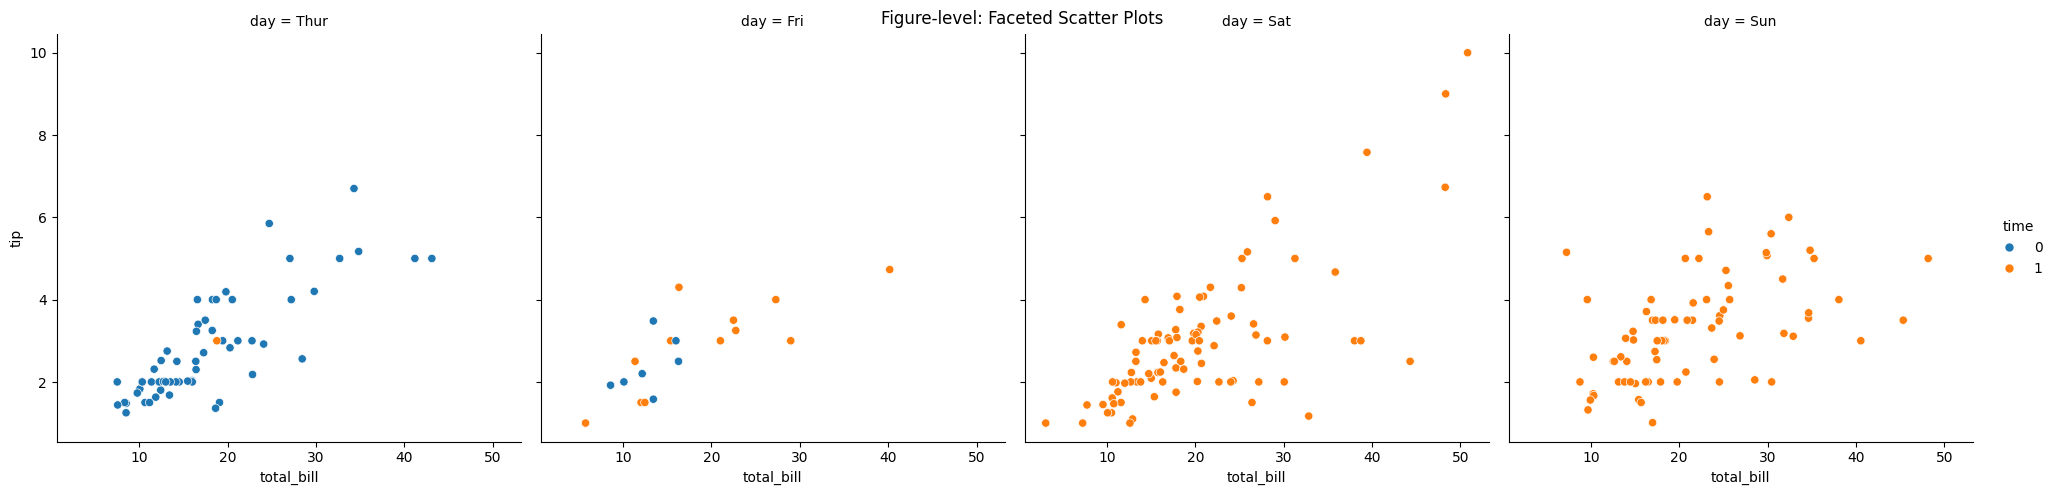

In [12]:
plt.figure(figsize=(18, 5))
sns.relplot(data=tips_df, x="total_bill", y="tip", hue="time", col="day", kind="scatter")
plt.suptitle("Figure-level: Faceted Scatter Plots")

**Note:**

Seaborn maintains consistency by using similar parameter names across different functions. This consistency makes it easier to switch between plot types without learning entirely new syntax.

Common parameters include:

- `data`: The DataFrame containing the dataset
- `x`, `y`: Variables for x and y axes
- `hue`: Variable for color encoding
- `size`: Variable for size encoding
- `style`: Variable for style encoding (e.g., marker shapes)


An example:

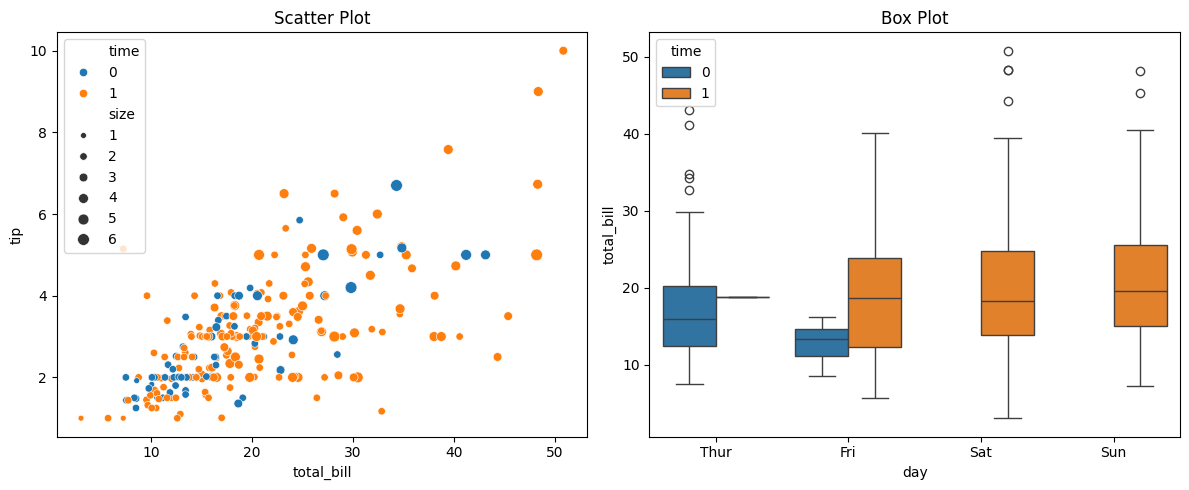

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
sns.scatterplot(data=tips_df, x="total_bill", y="tip", hue="time", size="size", ax=ax1)
ax1.set_title("Scatter Plot")
#, legend=False


# Box plot
sns.boxplot(data=tips_df, x="day", y="total_bill", hue="time", ax=ax2)
ax2.set_title("Box Plot")

plt.tight_layout()

🔑 **Key Insights:** 
- Note the distribution of tips. Is it normally distributed?
- Observe the relationship between total bill and tip. Does it appear linear?
- Look for any patterns in tipping based on categorical variables.

### Feature Engineering

🔑 **Key Concept:** Feature engineering allows us to incorporate domain knowledge and create new features that might capture important patterns in the data.


### Task: create tip percentage and per person total

In [14]:
tips_df['tip_percentage'] = tips_df['tip'] / tips_df['total_bill'] * 100
tips_df['per_person_total'] = tips_df['total_bill'] / tips_df['size']
tips_df

,total_bill,tip,sex,smoker,day,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total
0,16.99,1.01,1,1,Sun,1,2,False,False,False,True,5.944673,8.495000
1,10.34,1.66,0,1,Sun,1,3,False,False,False,True,16.054159,3.446667
2,21.01,3.50,0,1,Sun,1,3,False,False,False,True,16.658734,7.003333
3,23.68,3.31,0,1,Sun,1,2,False,False,False,True,13.978041,11.840000
4,24.59,3.61,1,1,Sun,1,4,False,False,False,True,14.680765,6.147500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,Sat,1,3,False,False,True,False,20.392697,9.676667
240,27.18,2.00,1,0,Sat,1,2,False,False,True,False,7.358352,13.590000
241,22.67,2.00,0,0,Sat,1,2,False,False,True,False,8.822232,11.335000
242,17.82,1.75,0,1,Sat,1,2,False,False,True,False,9.820426,8.910000


### Task: Is Weekend?

In [15]:
tips_df['is_weekend'] = (tips_df['day_Sat'] | tips_df['day_Sun']).astype(int)
tips_df

,total_bill,tip,sex,smoker,day,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend
0,16.99,1.01,1,1,Sun,1,2,False,False,False,True,5.944673,8.495000,1
1,10.34,1.66,0,1,Sun,1,3,False,False,False,True,16.054159,3.446667,1
2,21.01,3.50,0,1,Sun,1,3,False,False,False,True,16.658734,7.003333,1
3,23.68,3.31,0,1,Sun,1,2,False,False,False,True,13.978041,11.840000,1
4,24.59,3.61,1,1,Sun,1,4,False,False,False,True,14.680765,6.147500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,Sat,1,3,False,False,True,False,20.392697,9.676667,1
240,27.18,2.00,1,0,Sat,1,2,False,False,True,False,7.358352,13.590000,1
241,22.67,2.00,0,0,Sat,1,2,False,False,True,False,8.822232,11.335000,1
242,17.82,1.75,0,1,Sat,1,2,False,False,True,False,9.820426,8.910000,1


### Task: group (party) size category

In [16]:
#tips_df = tips_df.drop(columns=[col for col in tips_df.columns if col.startswith("party_")])

tips_df['party_size_category'] = pd.cut(tips_df['size'], bins=[0, 3, 6, np.inf], labels=['Small', 'Medium', 'Large'])
tips_df = pd.get_dummies(tips_df, columns=['party_size_category'], prefix='party')

#s_cols = [col for col in tips_df.columns if col.startswith('party_')]
#tips_df[s_cols] = tips_df[s_cols].astype(int)


tips_df

,total_bill,tip,sex,smoker,day,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,Sun,1,2,False,False,False,True,5.944673,8.495000,1,True,False,False
1,10.34,1.66,0,1,Sun,1,3,False,False,False,True,16.054159,3.446667,1,True,False,False
2,21.01,3.50,0,1,Sun,1,3,False,False,False,True,16.658734,7.003333,1,True,False,False
3,23.68,3.31,0,1,Sun,1,2,False,False,False,True,13.978041,11.840000,1,True,False,False
4,24.59,3.61,1,1,Sun,1,4,False,False,False,True,14.680765,6.147500,1,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,Sat,1,3,False,False,True,False,20.392697,9.676667,1,True,False,False
240,27.18,2.00,1,0,Sat,1,2,False,False,True,False,7.358352,13.590000,1,True,False,False
241,22.67,2.00,0,0,Sat,1,2,False,False,True,False,8.822232,11.335000,1,True,False,False
242,17.82,1.75,0,1,Sat,1,2,False,False,True,False,9.820426,8.910000,1,True,False,False


### Hypothesis Testing

### Task: Are there significant differences in tips across different weekdays?

In [17]:
import pandas as pd
from scipy import stats

tips_df = sns.load_dataset("tips")

# Subset data for Saturday and Sunday
tips_thur = tips_df[tips_df['day'] == 'Thur']['tip']
tips_sat = tips_df[tips_df['day'] == 'Sat']['tip']
tips_sun = tips_df[tips_df['day'] == 'Sun']['tip']

# Check basic statistics
print("Thursday tips mean:", tips_thur.mean())
print("Saturday tips mean:", tips_sat.mean())
print("Sunday tips mean:", tips_sun.mean())


print("\nTHURSDAY AND SUNDAY TIPS")

# Perform two-sample t-test (unequal variance)
t_stat, p_value = stats.ttest_ind(tips_thur, tips_sun, equal_var=False)

print("\nT-test result:")
print("t-statistic =", t_stat)
print("p-value =", p_value)

# Interpretation
if p_value < 0.05:
    print("Tips on Thursday and Sundays are significantly different (p < 0.05)")
else:
    print("No significant difference between tips on Thursday and Sundays (p ≥ 0.05)")


print("\nSATURDAY AND SUNDAY TIPS")

# Perform two-sample t-test (unequal variance)
t_stat, p_value = stats.ttest_ind(tips_sat, tips_sun, equal_var=False)

print("\nT-test result:")
print("t-statistic =", t_stat)
print("p-value =", p_value)

# Interpretation
if p_value < 0.05:
    print("Tips on Sundays and Saturdays are significantly different (p < 0.05)")
else:
    print("No significant difference between tips on Sundays and Saturdays (p ≥ 0.05)")

Thursday tips mean: 2.771451612903225
Saturday tips mean: 2.993103448275862
Sunday tips mean: 3.2551315789473687

THURSDAY AND SUNDAY TIPS

T-test result:
t-statistic = -2.283293453871007
p-value = 0.024032440317294304
Tips on Thursday and Sundays are significantly different (p < 0.05)

SATURDAY AND SUNDAY TIPS

T-test result:
t-statistic = -1.1643744529652282
p-value = 0.24602827507011615
No significant difference between tips on Sundays and Saturdays (p ≥ 0.05)
